# IQ Analyze Reaction Models Introduction

IQ Analyze is a proprietary software package that compiles models, runs simulations, scans parameters, and performs optimizations. Simulations are submitted through Python, run on a separate server, and returned as tables for further analysis in Python.

IQ Analyze can use a text-based model file, called a Reaction Model, that is converted into a set of ordinary differential equations (ODEs). This notebook demonstrates how to:

- Write a simple 2-compartment model using the text-based Reaction Model format.
- Generate parameter, dose, and simulation tables.
- Submit a simulation.
- View and plot the simulation output.

# Example Model

![Untitled.png](attachment:44b3fcc8-7ac0-4aad-a95f-22d1b4e33148.png)

This example uses *macroconstant* parameters to describe the model rates. The table below lists the relevant macroconstant parameters and their relationship to microconstant parameters:

| Macroconstant | Description | Conversion to microconstants |
|----------------|--------------|--------------------|
| \begin{align}\text{thalf}\end{align} | \begin{align}\text{Half life}\end{align} | $\text{kel} = \frac{\log(2)}{\text{thalf}}$|
| \begin{align}&\text{Pdist}\\& \\&\text{Tdist} \end{align}| \begin{align}& \text{Distribution partition}\\ & \\ & \text{Distribution half time} \end{align}| \begin{align} & \text{k12} = \frac{(\log(2) *  \text{Pdist})/\text{Tdist}}{(\text{Pdist} + (\text{V1}/\text{V2}))} \\ & \\ & \text{k21} = \frac{\log(2)/\text{Tdist}}{(1 + (\text{Pdist} * \text{V2}/\text{V1}))}\end{align}|
|\begin{align}\text{KD}\end{align} | \begin{align}\text{Affinity}\end{align}| $\text{koff} = \text{KD} * \text{kon}$|

Models can also be built directly with microconstants. Macroconstants are used here because they are commonly reported when presenting results, and they provide a concise way to define the reactions in this example.

# Model File

The `../Models` folder contains `ModelFile_TextBased.model`, a completed version of the model described in the following sections. Use this file as a reference or as a starting point for a new text-based model.

## Header
- Comments in this model file, as in Python, are denoted by `#`.
- Each model file begins with a section like this:
  
  ```
  %% ReactionModel@2
  initialization = steady_state(time_scale = 86400:s)
  time_unit = s
  default_state_unit = nmol
  % components
  ```
  The first line starts the model. The number `2` denotes a Version 2 model file. Version 1 models still run, but this example focuses on the newer Reaction Model version. The main user-facing difference between Version 1 and Version 2 is a small set of syntax changes.

  The second line determines the initialization method. The available options are `steady_state` and `initial_value`. The `steady_state` option runs a simulation to steady state, with the maximum allowed time for the steady-state calculation defined in parentheses. The `initial_value` option initializes the model from values defined later in the model file.

  The third and fourth lines define the default time and state units. This example uses seconds and nmol, respectively.

## Parameters

The next section defines parameters. Parameters are values that do not change during the simulation and are defined externally.

Each parameter should be defined on a separate line using `parameter:units := value`.

If `value` is a number, it is considered unitless by default. If parameter values are defined directly in the model file, any values with units must include the appropriate unit annotation using `:unit` after the value. Units on the left-hand side of the equation are optional and assert that the units on the right-hand side are equivalent to the declared units.

Many models do not include explicit parameter values in the model file. Instead, they use `parameter:units := nan` in the model file and provide parameter values through a parameter table. This approach makes parameter values easier to modify and simplifies QC. If `nan` is used on the right-hand side of the parameter definition, units MUST be included on the left-hand side.

### Parameter Setup
Add the following parameter definitions to the model in the space provided.

![image.png](attachment:96b4525e-3e30-4ae1-8359-01bc36bac6b3.png)

## Assignments

This section defines assignments. Assignments are calculated values that are not defined externally. Assignments use `assignment:unit = value or expression`.

There are three main types of assignments used in models:

1. Unit conversion rules, for example `mL_per_L:(mL/L) = 1000:(mL/L)`.
2. Functions of parameters, for example `thalf_s:s = thalf_h * 3600:(s/hr)`. If a parameter or assignment with defined units appears on the right-hand side of another assignment, units do not need to be repeated.
3. Functions of states, for example `drug_concentration:nM = drug_amount / volume`.

### Assignment Setup

Create assignments to calculate the initial state values:
- `total_cells_central`
- `total_R1_central`

## Routes
Routes define how doses are delivered into the model. There are three main options for dose routes:

1. List schedule: `@(times = ..., amounts = ..., durations = ...)`
2. Repeat schedule: `@(start = ..., interval = ..., n = ..., amount = ..., duration = ...)`
3. Null schedule: `@()`

It is usually recommended to use a null route in the model file. This allows the dose amount and dose frequency to be defined externally. If a List Schedule or Repeat Schedule route is used, the route remains "on" for all simulations. The null schedule option allows multiple possible routes to be defined and then selected for each simulation.

A null route is defined with the following syntax:

`Route_name: (units) = @();  State += amt * Conversion_to_state_units`

The example model file includes a prepared null route.

### Route Setup
Review the conversion between the dosed `amt` and the resulting change to the state variable.

## Compartments
Compartments define the appropriate volumes for each state variable. The syntax of a compartment is `name~dimension = size`.

- The compartment name is typically the tissue name and should be one word.
- The compartment dimension determines the types of reactions expected. Most compartments use a dimension of 3. For cases where only membrane-bound states interact and second-order reactions are needed, such as in the TCE template model, set the dimension equal to 2.

### Compartment Setup
Define two compartments with dimension 3 and volumes equal to the appropriate parameters:

1. `central`
2. `peripheral`

## States
This section lists all state variables, assigns them to their appropriate compartments, and defines their initial values. The syntax for defining a state is `name@compartment: unit *= initial_value`.

When using `steady_state` initialization, the initial value of a state only affects the amount of time and computational power required to initialize. When possible, calculate the desired initial values even when using `steady_state` initialization.

### State Setup
Define 4 states for the model:

1. `R1_central`: free receptor in the central compartment
2. `Ab1_00_central`: free drug in the central compartment
3. `Ab1_R1_central`: bound drug:receptor in the central compartment
4. `Ab1_peripheral`: free drug in the peripheral compartment

Choose the appropriate initial conditions.

## Reactions
This section defines the model reactions. Reactions are defined using arrows.

The general syntax of a reaction is:

`States before <-> States after ; kf = forward rate constant, kr = reverse rate constant`

If a reaction is irreversible, use the forward arrow (`->`) and omit the `kr` term.

The forward and reverse rate constants are the general rate constants used when defining a reaction. To explicitly define the reaction rate, or the derivative due to this specific reaction, use:

`States before <-> States after ; rf = forward rate, rr = reverse rate`

In addition to these general forms, Reaction Models include specific inputs that read macroconstant parameters:

| Reaction Type | Code | Notes |
|-|-|-|
|Synthesis/Degradation | ` <-> State; css = steady_state_concentration, thalf = Half_Life`| The `css` must be a *concentration*. The `thalf` must be defined in the same units as the default time units in the model file|
|Degradation| `State -> ; thalf = Half_life`| The `thalf` must be defined in the same units as the default time units in the model file|
|Binding| `A + B <-> C; kd = KD, kon = k_on` | The `kd` term must be in units consistent with the state units divided by the compartment volume units. The `kon` value must be in units consistent with `1/(state unit / volume unit)/time unit`|
|Transport| `A_compartment1 <-> A_compartment2; pdist = Pdist, tdist = Tdist`| The units of `Pdist` are 1, and the value should give the steady-state ratio of the concentration in compartment 1 to compartment 2. The units of `tdist` should match the default time units in the model file|

Additional special reaction types are available, but they are not needed for this example.

### Reaction Setup
Define 6 reactions using the states in the previous section:

1. Synthesis/degradation of receptor in the central compartment
2. Degradation of free drug in the central compartment
3. Degradation of bound drug:receptor in the central compartment
4. Degradation of free drug in the peripheral compartment
5. Binding/unbinding of drug to receptor in the central compartment
6. Transport of free drug between the central and peripheral compartment

## Model Readouts
This section defines an additional set of assignments that provide easy-to-read model outputs. These outputs may be identical to a state variable with a different name, a combination or sum of several state variables, or a transformation of a state variable, such as nmol to nM.

The syntax of a model readout is the same as an assignment: `name:unit = value`.

### Model Readout Setup
Define 5 model readouts:

1. `free_R1_central` with units `nmol` (identical to one of the state variables)
2. `free_drug_central` with units `nmol` (identical to one of the state variables)
3. `bound_drug_central` with units `nmol` (identical to one of the state variables)
4. `total_drug_central` with units of `nmol` (the sum of two state variables)
5. `RO` with units `1` (the percent of receptor that is bound)

# Running the Simulation
With the model file defined, the next step is setting up and running a simulation.

## Load Packages
Load the required Python packages. In addition to `numpy`, `pandas`, and `plotnine`, this notebook uses the QSP Notebook package `abm`.

Run a cell with:
```
import numpy as np
import pandas as pd
from plotnine import *
from abm import *
```

In [1]:
import numpy as np
import pandas as pd
from plotnine import *
from abm import *

## Setting Up the Tables
Several tables are required to interface with the simulation software: the parameter table, dose table, and simulation table. If parameters are defined explicitly in the model, the parameter table is optional; however, using a parameter table is recommended for easier review and modification.

These tables can be created with a CSV editor or with pandas. This example uses completed tables from the `../Parameters/TextBased_Tables` directory.

### Parameter Table
For simulations, a parameter table must have 3 columns:

1. `parameter` - the parameter name
2. `value` - the parameter value
3. `unit` - the parameter unit

Optional label columns can be added to distinguish between multiple conditions. For example, high and low expression conditions might have different `R_per_cell` values. For more details on labels, see the [video on Analyze Labels](https://fast.wistia.com/embed/channel/tr2ke8t6ts?wchannelid=tr2ke8t6ts&wmediaid=xo9t5i8qys).

### Dose Table
The dose table defines the doses, routes, and frequency of drug delivery. There are 6 required columns:

1. A label column - This names the specific delivery condition. In many cases, this can be the same as the dose, so the column is often called something like `dose_mpk`.
2. `route` - The route used for delivery. In this example, there is one route option: `IV_mpk`.
3. `amounts` - The amount of drug to be delivered.
4. `amount_unit` - The unit used for the dose amount. This may be different from the unit defined in the model, but it must be a consistent unit type. For example, if the model units are `mg/kg`, `g/kg` can be used in the dose table, but `mg` cannot.
5. `times` - The times at which the dose should be applied.
6. `time_unit` - The units for the dose times. This does not need to match the default model time unit, but it must be a valid time unit.

### Simulation Table
The simulation table contains the same label column as the dose table, with row entries that identify the conditions to simulate. To simulate every condition in the dose table, use the unique label rows from the dose table. To simulate only a subset of conditions, include only those label values in the simulation table.

### Table Setup
- Use the completed dose table in the `../Parameters/TextBased_Tables` folder. It contains 4 dose levels: 0.01 mg/kg, 0.03 mg/kg, 0.1 mg/kg, and 0.3 mg/kg. Each dose is applied at 3 time points: 0 days, 7 days, and 14 days.
- Use the completed simulation table in the `../Parameters/TextBased_Tables` folder. It selects all dose levels defined in the dose table.

## Submitting a Simulation
To run a simulation, use the `simulate` function from the `abm` package.

- The `models` input is the model file location.
- The `parameters` input is either the parameter file location or a loaded parameter table.
- The `simulations` input is either the simulation file location or a loaded simulation table.
- The `doses` input is either the dose file location or a loaded dose table.
- The `times` input defines the times at which simulation results should be saved. This can be a list of times with the format `['time:unit']`, or it can be created with the `linspace(start, stop, count, unit)` function from the `abm` package.
- The `outputs` input is a list of output state names to save.

Syntax:
```
simulate(models = {Model File},
        parameters = {Parameter Table},
        doses = {Dose Table},
        simulations = {Simulation Table},
        outputs = {Output List},
        times = {Times List or Table}).to_pandas(tall_outputs = True)
```

### Simulation Setup
- Load the parameter table, dose table, and simulation table as `Tpar`, `Tdos`, and `Tsim`.
- Fill in the following code with the model file, parameter table, dose table, and simulation table:
    - Select RO as the output.
    - Select days 0-21 with 211 samples as the output times.

In [2]:
Tpar = pd.read_csv('inputs/Parameters/TextBased_Tables/ParameterTable.csv')
Tdos = pd.read_csv('inputs/Parameters/TextBased_Tables/DoseTable_filled.csv')
Tsim = pd.read_csv('inputs/Parameters/TextBased_Tables/SimulationTable_filled.csv')

In [3]:
Tres = simulate(models = 'inputs/Models/ModelFile_TextBased.model',
                parameters = Tpar,
                doses = Tdos,
                simulations = Tsim,
                outputs = ['RO1'],
                times = linspace(0,21,211,'d')).to_pandas(tall_outputs = True)

Total: 0, Running: 0, Succeeded: 0, Failed: 0

In [4]:
# Display the first 5 rows of simulation results.
display(Tres.head())

,dose_mpk,id,t,output,value,output_unit
0,0.01,0,0.0,RO1,0.000000,1
1,0.01,0,8640.0,RO1,74.974506,1
2,0.01,0,17280.0,RO1,73.941215,1
3,0.01,0,25920.0,RO1,72.920454,1
4,0.01,0,34560.0,RO1,71.914931,1


### Plotting Results
Plot receptor occupancy over time for each dose level.

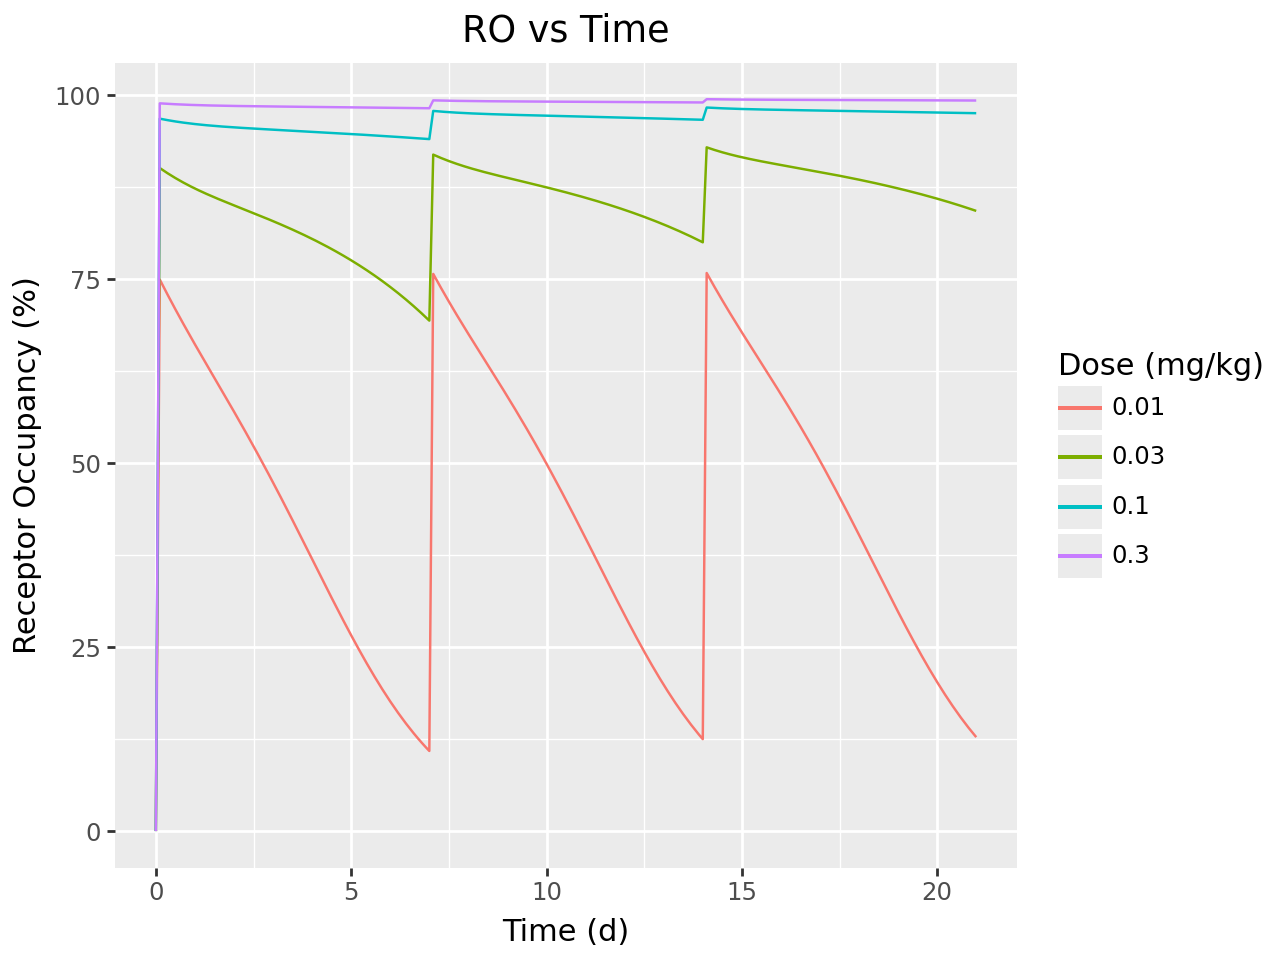

In [5]:
fig = (ggplot()
       + geom_line(data = Tres, mapping = aes(y = 'value', x = 't/(3600*24)', color = 'factor(dose_mpk)'))
       + labs(x = 'Time (d)', y = 'Receptor Occupancy (%)', color = 'Dose (mg/kg)', title = 'RO vs Time')
)

display(fig)